In [1]:
import jax
import jax.numpy as jnp

from ripplegw.constants import MSUN
from ripplegw.waveforms.imr_phenom_xphm.lal_sim_imr_phenom_x_internals_dataclass import (
    IMRPhenomXPHMParameterDataClass,
)
from ripplegw.waveforms.imr_phenom_xphm.lal_sim_imr_phenom_x import(
    xlal_imr_phenom_xp_msa_angles,
)
import lal
import lalsimulation as lalsim
from lalsimulation import SimIMRPhenomXPMSAAngles

import matplotlib.pyplot as plt

/home/robinc/jax_gw/ripple/src/ripplegw/waveforms/imr_phenom_xphm/lal_sim_imr_phenom_x.py:38: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [9]:
sampling_frequency=2048

freqs=jnp.linspace(20.0, sampling_frequency / 2.0, num=sampling_frequency)

m1_si=30.0 * MSUN
m2_si=20.0 * MSUN
chi1x=0.3
chi1y=0.2
chi1z=0.4
chi2x=0.1
chi2y=0.2
chi2z=0.3
inclination=0.0
f_ref_in=100.0
mprime=2
lal_params=IMRPhenomXPHMParameterDataClass(precession_version=220)

print("Computing MSA angles with ripple...")

alphas_ripple, gammas_ripple, cosbetas_ripple = xlal_imr_phenom_xp_msa_angles(
    freqs,
    m1_si,
    m2_si,
    chi1x,
    chi1y,
    chi1z,
    chi2x,
    chi2y,
    chi2z,
    inclination,
    f_ref_in,
    mprime,
    lal_params
)

laldict = lal.CreateDict()
lalsim.SimInspiralWaveformParamsInsertPhenomXPrecVersion(laldict, 220)

print("Computing MSA angles with LAL...")

alphas_lal, gammas_lal, cosbetas_lal = SimIMRPhenomXPMSAAngles(
    freqs,
    m1_si,
    m2_si,
    chi1x,
    chi1y,
    chi1z,
    chi2x,
    chi2y,
    chi2z,
    inclination,
    f_ref_in,
    mprime,
    laldict
)

# print("#" * 40)
# print("ripple MSA angles")
# print(f"alphas: {alphas_ripple}\ngammas: {gammas_ripple}\ncosbetas: {cosbetas_ripple}")
# print("#" * 40)
# print("lal MSA angles")
# print(f"alphas: {alphas_lal.data}\ngammas: {gammas_lal.data}\ncosbetas: {cosbetas_lal.data}")
# print("#" * 40)

Computing MSA angles with ripple...
Computing MSA angles with LAL...


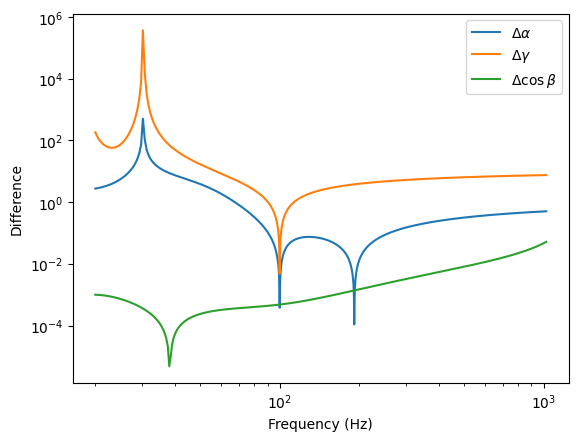

In [10]:
plt.plot(freqs, jnp.abs(alphas_ripple - alphas_lal.data), label=r'$\Delta \alpha$')
plt.plot(freqs, jnp.abs(gammas_ripple - gammas_lal.data), label=r'$\Delta \gamma$')
plt.plot(freqs, jnp.abs(cosbetas_ripple - cosbetas_lal.data), label=r'$\Delta \cos \beta$')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Difference")
plt.legend()

plt.xscale("log")
plt.yscale("log")
plt.show()